In [2]:
import sys
from types import ModuleType

# Workaround to mock all optional SpeechBrain packages and prevent Jupyter autoreload crashes
for target in [
    'speechbrain.integrations.k2_fsa',
    'speechbrain.integrations.nlp',
    'speechbrain.integrations.fairseq',
    'speechbrain.integrations.onnx',
    'speechbrain.integrations.pytorch_geometric'
]:
    if target not in sys.modules:
        sys.modules[target] = ModuleType(target.split('.')[-1])

# Now import the rest of your libraries
from langgraph.graph import StateGraph, START, END
# ... rest of your code ...

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal, List
from langgraph.graph import StateGraph, START, END

load_dotenv()

d:\factlens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [4]:
class DetectorResult(TypedDict, total=False):
    audio_languages: List[str]

In [5]:
class Segment(TypedDict):
    start: float
    end: float
    text: str
    confidence: float

In [6]:
# state
class FactLensState(TypedDict):
    video_path: str # given by user
    video_name: str
    video_size: int
    video_duration: Optional[float]

    valid: Literal[True, False]
    readable: Literal[True, False]
    error: str

    filename: str
    extension: Literal[".mp4", ".mov", ".mkv"]
    mime_type: str
    file_size_bytes: int
    file_size_mb: float
    duration_seconds: float
    fps: float
    frame_count: float
    resolution: str

    # store individual detector outputs
    whisper_result: DetectorResult
    mms_result: DetectorResult
    vox_result: DetectorResult
    speechbrain_result: DetectorResult

    audio_languages: List[str]
    ocr_languages: List[str]

    audio_path: str

    # segments: list[Segment]
    # segments_eng : list[Segment]

    # frame_paths : List[str]
    # ocr_segments: list[Segment1]
    # ocr_segments_eng: list[Segment1]

    # segments_ocr_audio: list[Segment2]

    # final_segments: list[Segment2]


In [17]:
# function that take the file path and return video file

from pathlib import Path

def get_video_file(file_path: str):
    """
    Returns an opened video file object if it exists.
    Returns None if the file doesn't exist.
    """
    path = Path(file_path)

    if not path.exists():
        print(f"File not found: {file_path}")
        return None

    return open(path, "rb")

In [7]:
import os
import cv2
import mimetypes
import os
import subprocess

def extract_audio(file_path: str) -> str:
    """Extracts audio from video and saves it to the temp1 folder as 16kHz mono WAV."""

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Input file not found at: {file_path}")

    ext = os.path.splitext(file_path)[1].lower()
    if ext in [".wav", ".mp3", ".m4a", ".flac", ".ogg"]:
        return file_path

    # Create temp1 folder in the current working directory
    temp_dir = "temp1"
    os.makedirs(temp_dir, exist_ok=True)

    # Output audio path
    audio_name = f"{os.path.splitext(os.path.basename(file_path))[0]}.wav"
    temp_audio_path = os.path.join(temp_dir, audio_name)

    # Remove existing file if present
    if os.path.exists(temp_audio_path):
        try:
            os.remove(temp_audio_path)
        except Exception:
            pass

    cmd = [
        "ffmpeg",
        "-y",
        "-i", file_path,
        "-vn",
        "-acodec", "pcm_s16le",
        "-ar", "16000",
        "-ac", "1",
        temp_audio_path,
    ]

    try:
        subprocess.run(
            cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            check=True,
        )
    except Exception as e:
        raise RuntimeError(f"FFmpeg audio extraction failed: {str(e)}")

    return temp_audio_path


def metadata_extraction_node(state: FactLensState) -> dict:
    video_path = state["video_path"]

    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")

    filename = os.path.basename(video_path)
    extension = os.path.splitext(filename)[1].lower()
    mime_type, _ = mimetypes.guess_type(video_path)
    file_size = os.path.getsize(video_path)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return {
            "valid": False,
            "readable": False,
            "error": "Unable to open video."
        }

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / fps if fps > 0 else 0

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    # Extract the audio ONCE here before starting parallel detection
    try:
        audio_path = extract_audio(video_path)
    except Exception as e:
        return {
            "valid": False,
            "readable": False,
            "error": f"Audio extraction failed: {str(e)}"
        }

    return {
        "valid": True,
        "filename": filename,
        "extension": extension,
        "mime_type": mime_type,
        "file_size_bytes": file_size,
        "file_size_mb": round(file_size / (1024 * 1024), 2),
        "duration_seconds": round(duration, 2),
        "fps": round(fps, 2),
        "frame_count": frame_count,
        "resolution": f"{width}x{height}",
        "readable": True,
        "audio_path": audio_path, # Saved to state
    }

In [8]:
import os
import tempfile
import subprocess
from collections import Counter

import cv2
import torch
import librosa
import whisper
import easyocr
from langdetect import detect_langs
from transformers import Wav2Vec2ForSequenceClassification, AutoFeatureExtractor
from speechbrain.inference.classifiers import EncoderClassifier

# Mapping ISO-639-3 (3-letter) outputs from facebook/mms-lid-401 to ISO-639-1 (2-letter)
MMS_ISO_MAP = {
    "hin": "hi", "eng": "en", "urd": "ur", "guj": "gu",
    "pan": "pa", "bng": "bn", "tam": "ta", "tel": "te",
    "kan": "kn", "mal": "ml", "mar": "mr", "ori": "or",
    "spa": "es", "fra": "fr", "deu": "de", "ita": "it",
    "rus": "ru", "zho": "zh", "jpn": "ja", "kor": "ko",
    "ara": "ar", "tur": "tr", "por": "pt", "vie": "vi"
}
# =====================================================================
# 2. AUDIO & OCR EXTRACTION HELPERS
# =====================================================================

def detect_ocr_languages(video_path: str) -> List[str]:
    """
    Runs separate compatible EasyOCR readers on video frames to detect 
    languages present in the visual text without script conflicts.
    """
    if not os.path.exists(video_path):
        return []
        
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30
        
    frame_interval = int(fps * 2)
    frame_count = 0
    extracted_texts = []
    
    # Initialize separate readers to avoid Devanagari (Hindi) and Arabic (Urdu) conflicts
    use_gpu = torch.cuda.is_available()
    reader_hi = easyocr.Reader(['en', 'hi'], gpu=use_gpu)
    reader_ur = easyocr.Reader(['en', 'ur'], gpu=use_gpu)
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        if frame_count % frame_interval == 0:
            # 1. Run Hindi / English OCR
            res_hi = reader_hi.readtext(frame, detail=0)
            if res_hi:
                extracted_texts.extend(res_hi)
                
            # 2. Run Urdu / English OCR
            res_ur = reader_ur.readtext(frame, detail=0)
            if res_ur:
                extracted_texts.extend(res_ur)
                
        frame_count += 1
        if frame_count > fps * 30:
            break
            
    cap.release()
    
    combined_text = " ".join(extracted_texts).strip()
    if not combined_text:
        return []
        
    detected_languages = []
    try:
        predictions = detect_langs(combined_text)
        for pred in predictions:
            if pred.prob > 0.2:
                detected_languages.append(pred.lang)
    except Exception:
        pass
        
    return sorted(list(set(detected_languages)))
# =====================================================================
# 3. ACTUAL MODEL CLASSIFICATION LOGIC
# =====================================================================
def run_whisper_audio(audio_path: str) -> List[str]:
    try:
        model = whisper.load_model("tiny")
        audio = whisper.load_audio(audio_path)
        audio = whisper.pad_or_trim(audio)
        
        mel = whisper.log_mel_spectrogram(audio).to(model.device)
        _, probs = model.detect_language(mel)
        detected = max(probs, key=probs.get)
        return [detected] if detected else []
    except Exception as e:
        print(f"[Whisper Error] {e}")
        return []
    
def run_mms_audio(audio_path: str) -> List[str]:
    """Facebook MMS-LID-4017 Hugging Face model execution to detect language."""
    try:
        # Corrected model identifier: added '7' to the end
        model_name = "facebook/mms-lid-4017"
        processor = AutoFeatureExtractor.from_pretrained(model_name)
        model = Wav2Vec2ForSequenceClassification.from_pretrained(model_name)
        
        speech, _ = librosa.load(audio_path, sr=16000)
        inputs = processor(speech, sampling_rate=16000, return_tensors="pt")
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        predicted_id = torch.argmax(outputs.logits, dim=-1).item()
        lang_3 = model.config.id2label[predicted_id]
        
        lang_2 = MMS_ISO_MAP.get(lang_3.lower(), lang_3)
        return [lang_2] if lang_2 else []
    except Exception as e:
        print(f"[MMS Error] {e}")
        return []


def run_speechbrain_audio(audio_path: str) -> List[str]:
    """CommonLanguage ECAPA model execution via SpeechBrain."""
    try:
        # Save model inside local project directory to help avoid Windows cross-volume symlink errors
        model_dir = "./model_cache/sb_cv"
        
        # Corrected model identifier to the public commonlanguage_ecapa model
        classifier = EncoderClassifier.from_hparams(
            source="speechbrain/lang-id-commonlanguage_ecapa", 
            savedir=model_dir
        )
        signal = classifier.load_audio(audio_path)
        prediction = classifier.classify_batch(signal)
        label = prediction[3][0]
        detected = label.split(":")[0].strip()
        return [detected] if detected else []
    except Exception as e:
        print(f"[SpeechBrain Error] {e}")
        return []


def run_voxlingua_audio(audio_path: str) -> List[str]:
    """VoxLingua107 ECAPA-TDNN model execution via SpeechBrain."""
    try:
        # Save model inside local project directory to help avoid Windows cross-volume symlink errors
        model_dir = "./model_cache/sb_vox"
        
        classifier = EncoderClassifier.from_hparams(
            source="speechbrain/lang-id-voxlingua107-ecapa", 
            savedir=model_dir
        )
        signal = classifier.load_audio(audio_path)
        prediction = classifier.classify_batch(signal)
        label = prediction[3][0]
        detected = label.split(":")[0].strip()
        return [detected] if detected else []
    except Exception as e:
        print(f"[VoxLingua Error] {e}")
        return []
# =====================================================================
# 4. PARALLEL NODES (Corrected to use video_path)
# =====================================================================
def whisper_audio_detection(state: FactLensState) -> dict:

    audio_path = state.get("audio_path")

    if not audio_path:
        return {
            "whisper_result": {
                "audio_languages": []
            }
        }

    return {
        "whisper_result": {
            "audio_languages": run_whisper_audio(audio_path)
        }
    }

def mms_lid_401_audio_detection(state: FactLensState) -> dict:

    audio_path = state.get("audio_path")

    if not audio_path:
        return {
            "mms_result": {
                "audio_languages": []
            }
        }

    return {
        "mms_result": {
            "audio_languages": run_mms_audio(audio_path)
        }
    }

def voxlingua107_audio_detection(state: FactLensState) -> dict:

    audio_path = state.get("audio_path")

    if not audio_path:
        return {
            "vox_result": {
                "audio_languages": []
            }
        }

    return {
        "vox_result": {
            "audio_languages": run_voxlingua_audio(audio_path)
        }
    }

def speechbrain_audio_detection(state: FactLensState) -> dict:

    audio_path = state.get("audio_path")

    if not audio_path:
        return {
            "speechbrain_result": {
                "audio_languages": []
            }
        }

    return {
        "speechbrain_result": {
            "audio_languages": run_speechbrain_audio(audio_path)
        }
    }
# =====================================================================
# 5. CONSOLIDATING / MERGER NODE LOGIC
# =====================================================================
def flatten_languages(audio_lists: List[List[str]]) -> List[str]:
    return [lang for sublist in audio_lists if sublist for lang in sublist if lang]
def majority_vote(state: FactLensState) -> List[str]:
    priority_keys = ["mms_result", "speechbrain_result", "vox_result", "whisper_result"]
    audio_lists = []
    
    for key in priority_keys:
        res = state.get(key)
        if isinstance(res, dict):
            audio_lists.append(res.get("audio_languages", []))
        else:
            audio_lists.append([])
            
    flattened = flatten_languages(audio_lists)
    if not flattened:
        return []
        
    counter = Counter(flattened)
    max_count = max(counter.values())
    candidates = [lang for lang, count in counter.items() if count == max_count]
    
    if len(candidates) == 1:
        return [candidates[0]]
        
    candidate_best_priority = {}
    for cand in candidates:
        for idx, key in enumerate(priority_keys):
            res = state.get(key)
            if isinstance(res, dict) and cand in res.get("audio_languages", []):
                candidate_best_priority[cand] = idx
                break
        else:
            candidate_best_priority[cand] = len(priority_keys)
            
    winner = min(candidates, key=lambda c: candidate_best_priority[c])
    return [winner]

def final_audio_selection(state: FactLensState) -> dict:

    return {
        "audio_languages": majority_vote(state),
        "ocr_languages": state.get("ocr_languages", [])
    }

In [9]:
def ocr_language_detection(state: FactLensState) -> dict:
    """
    Detect OCR languages once and store them in state.
    """

    video_path = state.get("video_path")

    if not video_path:
        return {"ocr_languages": []}

    ocr_langs = detect_ocr_languages(video_path)

    return {
        "ocr_languages": ocr_langs
    }

In [ ]:
# ignore it =========================================================

import os
import cv2
import tempfile
from collections import Counter

from rapidocr_onnxruntime import RapidOCR
from langdetect import detect, LangDetectException
from faster_whisper import WhisperModel
from moviepy import VideoFileClip


# Initialize once
ocr = RapidOCR()
whisper = WhisperModel("base", device="cpu")


def language_detection_node(state: FactLensState) -> dict:
    """
    Detect all languages present in audio and OCR.

    Returns:
    {
        "audio_languages": ["en", "hi"],
        "ocr_languages": ["en"]
    }
    """

    video_path = state["video_path"]

    # =====================================================
    # AUDIO LANGUAGE DETECTION (Highest Priority)
    # =====================================================

    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        audio_path = tmp.name

    try:

        VideoFileClip(video_path).audio.write_audiofile(
            audio_path,
            logger=None
        )

        segments, _ = whisper.transcribe(
            audio_path,
            vad_filter=True
        )

        audio_counter = Counter()

        buffer = ""

        # Merge transcript into larger chunks
        for segment in segments:

            text = segment.text.strip()

            if not text:
                continue

            buffer += " " + text

            # Detect every ~250 characters
            if len(buffer) >= 250:

                try:
                    lang = detect(buffer)
                    audio_counter[lang] += 1
                except LangDetectException:
                    pass

                buffer = ""

        # Remaining text
        if buffer.strip():
            try:
                lang = detect(buffer)
                audio_counter[lang] += 1
            except LangDetectException:
                pass

    finally:

        if os.path.exists(audio_path):
            os.remove(audio_path)

    # Keep every detected language
    audio_languages = sorted(audio_counter.keys())

    # =====================================================
    # OCR LANGUAGE DETECTION (Lightweight)
    # =====================================================

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Only one frame every 3 seconds
    sample_interval = max(1, int(fps * 3))

    ocr_counter = Counter()

    for frame_no in range(0, total_frames, sample_interval):

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)

        success, frame = cap.read()

        if not success:
            continue

        result, _ = ocr(frame)

        if not result:
            continue

        text = " ".join(
            line[1]
            for line in result
        ).strip()

        if len(text) < 10:
            continue

        try:
            lang = detect(text)
            ocr_counter[lang] += 1
        except LangDetectException:
            pass

    cap.release()

    # Keep languages seen at least twice
    ocr_languages = sorted([
        lang
        for lang, count in ocr_counter.items()
        if count >= 2
    ])

    return {
        "audio_languages": audio_languages,
        "ocr_languages": ocr_languages
    }

In [10]:
from pathlib import Path
from faster_whisper import WhisperModel


# Load the model once (global)
WHISPER_MODEL = WhisperModel(
    "small",          # tiny, base, small, medium, large-v3
    device="cpu",     # change to "cuda" if using NVIDIA GPU
    compute_type="int8"
)


def transcribe_audio(audio_path: str) -> dict:
    """
    Transcribe an audio file in its original language.

    Args:
        audio_path (str): Path to the audio file.

    Returns:
        dict:
        {
            "language": "<detected_language>",
            "text": "<complete_transcription>"
        }
    """

    audio_path = Path(audio_path)

    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found: {audio_path}")

    segments, info = WHISPER_MODEL.transcribe(
        str(audio_path),
        beam_size=5,
        vad_filter=True,
        task="transcribe",   # Keeps original language
    )

    full_text = " ".join(segment.text.strip() for segment in segments).strip()

    return {
        "language": info.language,
        "text": full_text
    }

a = transcribe_audio("D:/factlens/temp1/video.wav")

print(a)

d:\factlens\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rudra\.cache\huggingface\hub\models--Systran--faster-whisper-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


{'language': 'hi', 'text': 'लगातार कै देनों से चल रहें कोग्रुज जन्ता पाटी के इसा अंदूलन में बले वले सेलबिटीस किस के साथ हैं चलो जानते हैं तो सब से पहले सल्मान कान ने कहा पहले ये पीस्पल प्रोटेश्टा लेकना विसने हिंसक्मोल अपना लिया है और मुझे बाकए बहुत दोखो रहे हैं और इसके बाद बबे कोबरोटेन का बैं आपी नेता हु नेता नहीं इं सब चीजों से मुझे दूर रहों और दिल्जीत पाजी ने भी इस पर्ष्ट रूप से कै दिया है में एक आटेष्टूम मुझे इन सब चीजों से दूरी रहो बाई लेकें प्रकास राज यो फिल्मो में बिलें का रोल ने बाते हैं और नहोंने CJP को CJP के प्रोटेष्ट में जाकरी सपोट किया है बाई और नके सासात रप्ता अर्थारा बाई जोगंदर पुनिस सुपर स्ता'}


In [14]:
import os
import cv2
import base64
import tempfile
from PIL import Image

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage


# Initialize Gemini once
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)


def image_to_base64(image_path: str) -> str:
    """
    Convert image to Base64 Data URI.
    """
    with open(image_path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")

    return f"data:image/jpeg;base64,{encoded}"


def describe_video(
    video_path: str,
    sample_interval: float = 2.0,
) -> str:
    """
    Describe the complete visual context of a video.

    Args:
        video_path: Path to video.
        sample_interval: Seconds between sampled frames.

    Returns:
        Complete video description.
    """

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Unable to open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)

    frame_interval = max(1, int(fps * sample_interval))

    contents = []

    frame_index = 0

    with tempfile.TemporaryDirectory() as temp_dir:

        while True:

            success, frame = cap.read()

            if not success:
                break

            if frame_index % frame_interval == 0:

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                frame_path = os.path.join(
                    temp_dir,
                    f"frame_{frame_index}.jpg"
                )

                Image.fromarray(rgb).save(frame_path)

                contents.append(
                    {
                        "type": "image_url",
                        "image_url": image_to_base64(frame_path),
                    }
                )

            frame_index += 1

    cap.release()

    prompt = """
These images are sampled from the same video.

Analyze all images together and understand the complete visual content.

Return one comprehensive paragraph describing the entire video.

Include:

- Overall scene and setting
- Important people (identify well-known public figures only if reasonably confident)
- Actions and interactions
- Important objects
- Logos, banners and symbols
- All visible on-screen text exactly as written
- Any charts, posters, documents or screenshots shown
- Any information that helps understand the video's context

Rules:

- Preserve all visible text in its original language.
- Never translate any visible text.
- Merge all observations into one continuous description.
- Ignore repeated frames and camera angle changes.
- Do not mention timestamps.
- Do not list frames.
- Do not use bullet points.
- Do not explain your reasoning.

Return only the final descriptive paragraph.
"""

    response = llm.invoke(
        [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": prompt,
                    },
                    *contents,
                ]
            )
        ]
    )

    return response.content

description = describe_video(
    "D:/factlens/video.mp4",
    sample_interval=2
)

print(description)

The video presents a compilation of scenes related to a protest, consistently featuring the on-screen text "💀CJP PROTEST REALITY💀" with skull emojis. The overall setting includes large outdoor gatherings, both during the day and at night, with crowds of people participating in demonstrations. A police "VAJRA VAN" is visible amidst a dense crowd, many of whom are holding up mobile phones. Other scenes show police personnel in khaki uniforms and riot gear, yellow barricades, and an Indian flag being waved. One red banner with white text reads "EDUCATED YOUTH - ASSET TO THE COUNTRY". Several public figures are shown making statements or appearing at the protest: a man identified as Salman Khan is associated with a Hindi text overlay that reads, "ये आंदोलन इतना शांतिपूर्ण था. वाकई बहुत दुख हो रहा है कि इसे हिंसक मोड़ लेना पड़ा. जिन छात्रों को चोट लगी है और उनके परिवारों के लिए मेरी दिल से दुआएं और संवेदनाएं हैं."; Vivek Oberoi is seen speaking into microphones from "ANI" and "VNS"; Diljit 

In [16]:
def rebuild_context(text: str) -> str:
    """
    Rebuild a noisy transcript into a coherent contextual passage.

    Args:
        text (str): Raw transcript.

    Returns:
        str: Contextually reconstructed text.
    """

    if not text or not text.strip():
        return ""

    prompt = f"""
You are an expert at reconstructing transcripts.

The following text comes from automatic speech recognition (ASR) and may contain:
- Missing punctuation
- Missing capitalization
- Broken sentences
- Repeated words
- Filler words
- Minor recognition mistakes
- Poor sentence flow

Your task is to rewrite the text into one coherent passage while preserving the original meaning.

Rules:
1. Preserve every factual statement.
2. Do NOT add any new information.
3. Do NOT remove important information.
4. Fix grammar and punctuation.
5. Improve sentence flow.
6. Resolve references using nearby context when possible.
7. Keep the language exactly the same as the input.
8. Do NOT translate.
9. Return only the reconstructed text.

Transcript:

{text}
"""

    response = llm.invoke(
        [
            HumanMessage(
                content=prompt
            )
        ]
    )

    return response.content.strip()

c = rebuild_context(a["text"])
print(c)

लगातार कई दिनों से चल रहे कांग्रेस जनता पार्टी के इस आंदोलन में बड़े-बड़े सेलिब्रिटीज किसके साथ हैं, चलो जानते हैं। तो सबसे पहले सलमान खान ने कहा, "पहले ये पीसफुल प्रोटेस्ट था, लेकिन इसने हिंसक मोड़ अपना लिया है और मुझे वाकई बहुत दुख हो रहा है।" और इसके बाद बब्बू मान का बयान आया, "मैं कोई नेता नहीं हूं। इन सब चीजों से मुझे दूर रखो।" और दिलजीत पाजी ने भी स्पष्ट रूप से कह दिया है, "मैं एक आर्टिस्ट हूं। मुझे इन सब चीजों से दूरी रखो भाई।" लेकिन प्रकाश राज, जो फिल्मों में विलेन का रोल निभाते हैं, उन्होंने CJP को CJP के प्रोटेस्ट में जाकर सपोर्ट किया है भाई। और उनके साथ रैपर अर्थात भाई जोगिंदर पुनीत सुपरस्टार।


In [17]:
def translate_to_english(text: str, source_language: str) -> str:
    """
    Translate text to English only if it is not already English.

    Args:
        text (str): Input text.
        source_language (str): Language code or language name
            Examples:
                "en", "eng", "english"
                "hi", "hindi"
                "gu", "gujarati"
                "ur", "urdu"

    Returns:
        str: English text.
    """

    # Empty text
    if not text or not text.strip():
        return ""

    # Normalize language
    source_language = (source_language or "").strip().lower()

    # Skip translation if already English
    ENGLISH_LANGUAGES = {
        "en",
        "eng",
        "english"
    }

    if source_language in ENGLISH_LANGUAGES:
        return text

    prompt = f"""
You are a professional translator for a fact-checking system.

Translate the following text into fluent English.

Rules:
- Preserve every factual claim exactly.
- Do not summarize.
- Do not add information.
- Do not remove information.
- Preserve names, dates, numbers, quotations and URLs.
- Return ONLY the English translation.

Source Language: {source_language}

Text:
{text}
"""

    response = llm.invoke(
        [
            HumanMessage(content=prompt)
        ]
    )

    return response.content.strip()

d = translate_to_english(c,"hi")

In [18]:
print(d)

Let's find out which major celebrities are supporting this ongoing Congress Janata Party movement that has been going on for several days. So, first, Salman Khan said, "Initially, this was a peaceful protest, but it has taken a violent turn, and I am truly very saddened." And after this, Babbu Maan's statement came, "I am not a politician. Keep me away from all these things." And Diljit Paaji has also clearly stated, "I am an artist. Keep me away from all these things, brother." However, Prakash Raj, who plays villain roles in films, has supported CJP by going to CJP's protest, brother. And with him were rapper, that is, Bhai Joginder Puneet Superstar.


In [ ]:
def merge_multimodal_context(audio_context: str,visual_context: str,) -> str:
    """
    Merge audio and visual context into one coherent passage.

    Args:
        audio_context: Context reconstructed from speech.
        visual_context: Context reconstructed from video frames.

    Returns:
        A single contextual passage.
    """

    audio_context = (audio_context or "").strip()
    visual_context = (visual_context or "").strip()

    if not audio_context and not visual_context:
        return ""

    if not audio_context:
        return visual_context

    if not visual_context:
        return audio_context

    prompt = f"""
You are an expert multimodal context reconstruction system for a fact-checking pipeline.

You are given two independent descriptions of the SAME video.

The first comes from speech transcription.
The second comes from visual understanding.

Your task is to merge them into ONE coherent contextual passage.

-------------------------
Speech Context

{audio_context}

-------------------------
Visual Context

{visual_context}

-------------------------

Instructions:

1. Produce ONE coherent paragraph.

2. Preserve every factual statement supported by either source.

3. Use the visual context to resolve ambiguous, incomplete, or incorrect speech transcription whenever the visual evidence clearly supports the correction.

4. If both sources disagree:
   - Prefer the interpretation that is better supported by the combined context.
   - Never invent new facts.

5. Correct obvious transcription mistakes when the visual evidence makes the intended meaning clear.

6. Preserve:
   - names
   - organizations
   - locations
   - dates
   - numbers
   - quotations
   - visible text

7. Remove duplicated information.

8. Improve readability.

9. Do NOT summarize.

10. Do NOT explain your reasoning.

11. Return ONLY the final reconstructed contextual passage.
"""

    response = llm.invoke(
        [
            HumanMessage(content=prompt)
        ]
    )

    return response.content.strip()

e = merge_multimodal_context(d, description)

print(e)

The video presents a compilation of scenes related to the ongoing "Congress Janata Party (CJP)" movement, consistently featuring the on-screen text "💀CJP PROTEST REALITY💀" with skull emojis, indicating it has been going on for several days. The overall setting includes large outdoor gatherings, both during the day and at night, with crowds of people participating in demonstrations. A police "VAJRA VAN" is visible amidst a dense crowd, many of whom are holding up mobile phones. Other scenes show police personnel in khaki uniforms and riot gear, yellow barricades, and an Indian flag being waved. One red banner with white text reads "EDUCATED YOUTH - ASSET TO THE COUNTRY". Actions include people waving, running, and engaging in confrontations with police, with one instance showing a person swinging a stick. Photographers in orange vests are also present, capturing the events, and a blue vehicle with an "Amul" logo is seen among the protestors in one wide shot. Several public figures are s

In [26]:
import json

def extract_claims(text: str) -> list[dict]:
    """
    Extract only the important factual claims from text.

    Args:
        text (str)

    Returns:
        [
            {"claim": "..."},
            {"claim": "..."},
            ...
        ]
    """

    if not text or not text.strip():
        return []

    prompt = """
You are an expert claim extraction system for a multimodal fact-checking pipeline.

Your task is to extract ONLY the important, high-value, independently verifiable factual claims from the provided text.

The input text is already a reconstructed multimodal context (speech + visual information).

A claim should be extracted ONLY if it is meaningful enough to be independently verified using reliable sources.

========================
Extract ONLY claims such as:

• Statements made by identifiable public figures.
• Claims that a public figure supported, opposed, attended, joined, endorsed, announced, denied or participated in an event.
• Political claims.
• Government-related claims.
• Election-related claims.
• Health or medical claims.
• Scientific or technological claims.
• Economic or financial claims.
• Historical claims.
• Legal claims.
• Crime or security claims.
• Environmental claims.
• Numerical or statistical claims.
• Statements containing dates, places, organizations or measurable facts.
• Any statement asserting that an event happened.

========================
DO NOT extract:

• Greetings.
• Introductions.
• Conclusions.
• Opinions that cannot be fact-checked.
• Emotional statements.
• Camera descriptions.
• Scene descriptions.
• Clothing descriptions.
• Facial expressions.
• Crowd descriptions.
• Background objects.
• Weather.
• Logos.
• Watermarks.
• Emojis.
• Decorative text.
• Video editing effects.
• Camera angles.
• Visual aesthetics.
• Repeated information.
• Descriptions like:
    - people holding phones
    - police standing
    - flags waving
    - vehicles visible
    - photographers present
    - banners unless the banner itself makes a factual assertion
    - someone smiling
    - someone walking
    - someone holding a dog
    - someone wearing a specific color
    - crowd size unless explicitly claimed

========================
Important Rules

1. Extract ONLY claims worth fact-checking.

2. Remove unnecessary words while preserving the complete factual meaning.

3. Merge duplicate or overlapping claims.

4. If multiple sentences describe the SAME person, organization, event, or topic, combine them into ONE complete claim whenever they refer to the same factual event.

Example:
Instead of:
- Prakash Raj supported CJP.
- Prakash Raj went to CJP's protest.
- Prakash Raj interacted with people during the protest.

Return:
- Prakash Raj attended and supported the CJP protest, where he interacted with people.

Another example:
Instead of:
- Salman Khan said the protest was peaceful.
- Salman Khan said it later became violent.
- Salman Khan expressed sympathy for injured students.

Return:
- Salman Khan stated that the protest was initially peaceful, later turned violent, and expressed sympathy for the injured students and their families.

5. Preserve the exact factual meaning while merging related claims.

6. Never merge unrelated facts into one claim.

7. Do NOT invent facts.

8. Do NOT infer facts that are not explicitly stated.

9. Preserve names, organizations, locations, dates, quotations and numbers exactly.

10. If a public figure makes multiple related factual statements in the same context, combine them into a single claim.

11. If a public figure only appears on screen without making or being associated with a factual claim, DO NOT extract it.

12. Assign EXACTLY ONE claim type to every extracted claim.

Choose ONLY one of the following claim types:

- Political
- Government
- Election
- International Relations
- Military
- Crime
- Law
- Court
- Health
- Medical
- Science
- Technology
- Artificial Intelligence
- Cybersecurity
- Environment
- Climate
- Economy
- Business
- Finance
- Education
- History
- Religion
- Sports
- Entertainment
- Celebrity
- Social Media
- Meme
- Advertisement
- Product
- Company
- Employment
- Infrastructure
- Disaster
- Weather
- Transportation
- Agriculture
- Energy
- Public Safety
- Statistics
- Demographic
- Human Rights
- Fact Check
- Miscellaneous

13. Select the SINGLE most appropriate claim type.

14. If there are no fact-checkable claims, return an empty list.

15. Return ONLY valid JSON.

Return format:

[
    {{
        "claim": "..."
    }},
    {{
        "claim": "..."
    }}
]

Text:

"""

    prompt += text

    response = llm.invoke(
        [
            HumanMessage(content=prompt)
        ]
    )

    content = response.content.strip()

    # Remove Markdown code fences if present
    if content.startswith("```"):
        lines = content.splitlines()
        content = "\n".join(lines[1:])

        if content.startswith("json"):
            content = content[4:].strip()

        if content.endswith("```"):
            content = content[:-3].strip()

    try:
        claims = json.loads(content)
    except json.JSONDecodeError:
        return []

    return claims

f = extract_claims(e)
print(f)

[{'claim': 'The "Congress Janata Party (CJP)" movement is ongoing and has been going on for several days.', 'claim_type': 'Political'}, {'claim': 'A banner at the protest reads "EDUCATED YOUTH - ASSET TO THE COUNTRY".', 'claim_type': 'Political'}, {'claim': 'During the protest, people engaged in confrontations with police, and one instance showed a person swinging a stick.', 'claim_type': 'Public Safety'}, {'claim': 'Salman Khan stated that the movement was peaceful but sadly took a violent turn, expressing heartfelt prayers and condolences for the injured students and their families.', 'claim_type': 'Political'}, {'claim': 'Babbu Maan stated he is not a politician and asked to be kept away from "all these things".', 'claim_type': 'Celebrity'}, {'claim': 'Diljit Dosanjh stated he is an artist and asked to be kept away from "all these things".', 'claim_type': 'Celebrity'}, {'claim': 'Prakash Raj supported the CJP protest, attended it, interacted with people, and was seen lying on a bed,

In [27]:
import os
import json
import re

def fact_check_claims(claims: list) -> list:
    """
    Fact-checks a list of claims using Gemini.
    Skips any claim whose type belongs to 'Social_Media_and_Viral_Content' or 'Media_and_Digital_Content'.
    """
    # 1. Define cluster mappings to check skip conditions
    clusters = {
        "Politics_and_Governance": ["Political", "Government", "Election", "International Relations", "Military", "Law", "Court", "Human Rights"],
        "Crime_and_Public_Safety": ["Crime", "Public Safety", "Disaster"],
        "Health_and_Science": ["Health", "Medical", "Science", "Environment", "Climate"],
        "Technology_and_Digital": ["Technology", "Artificial Intelligence", "Cybersecurity"],
        "Economy_and_Business": ["Economy", "Business", "Finance", "Company", "Product", "Advertisement", "Employment"],
        "Entertainment_and_Celebrity": ["Celebrity", "Actor", "Actress", "Director"],
        "Media_and_Digital_Content": ["Movie", "TV Show", "Web Series", "Music", "Song", "Singer", "Dance", "Social Media", "Meme", "YouTube", "Instagram", "Facebook", "X (Twitter)", "OTT", "Influencer"],
        "Education_and_Society": ["Education", "History", "Religion", "Sports"],
        "Infrastructure_and_Resources": ["Infrastructure", "Transportation", "Agriculture", "Energy", "Weather"],
        "Data_and_Statistics": ["Statistics", "Demographic"],
        "Fact_Check_and_Other": ["Fact Check", "Miscellaneous"],
    }
    
    # Define what clusters/types should trigger a skip
    skip_clusters = {"Media_and_Digital_Content"}
    results = []

    for item in claims:
        claim = item.get("claim", "")
        claim_type = item.get("claim_type", "")
        
        # Determine if the claim_type belongs to a skipped cluster
        parent_cluster = next((cluster for cluster, types in clusters.items() if claim_type in types), "Unknown")
        
        if claim_type in skip_clusters or parent_cluster in skip_clusters:
            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": "Skipped — claim type falls under social media / viral content.",
                "confidance_score": "N/A",
                "resources_of_checking": ""
            })
            continue

        # Fact check using Gemini
        try:
            prompt = f"""
            Fact-check this claim: "{claim}"
            
            Return ONLY a raw JSON object (no markdown formatting, no ```json code block fences, no preamble) in this exact shape:
            {{
              "fact": "Maximum 2-3 lines explaining whether the claim is true or false and the context",
              "confidance_score": "A score from 0 to 100",
              "resources_of_checking": "A single URL link to the source used for checking"
            }}
            """
            
            # Invoke Gemini through LangChain
            response = llm.invoke(prompt)
            
            # Clean and extract the JSON response
            match = re.search(r"\{.*\}", response.content, re.DOTALL)
            parsed = json.loads(match.group(0)) if match else {}
            
            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": parsed.get("fact", "Unable to parse fact context."),
                "confidance_score": str(parsed.get("confidance_score", "N/A")),
                "resources_of_checking": parsed.get("resources_of_checking", "")
            })
            
        except Exception as e:
            results.append({
                "claim": claim,
                "claim_type": claim_type,
                "fact": f"Error during checking: {str(e)}",
                "confidance_score": "0",
                "resources_of_checking": ""
            })

    return results

output = fact_check_claims(f)
print(json.dumps(output, indent=2, ensure_ascii=False))

[
  {
    "claim": "The \"Congress Janata Party (CJP)\" movement is ongoing and has been going on for several days.",
    "claim_type": "Political",
    "fact": "The claim is false. There is no widely recognized or reported political movement or party named 'Congress Janata Party (CJP)' that is currently ongoing in India.",
    "confidance_score": "100",
    "resources_of_checking": "https://www.google.com/search?q=Congress+Janata+Party+CJP+movement+ongoing"
  },
  {
    "claim": "A banner at the protest reads \"EDUCATED YOUTH - ASSET TO THE COUNTRY\".",
    "claim_type": "Political",
    "fact": "The claim is true. Banners with the exact text \"EDUCATED YOUTH - ASSET TO THE COUNTRY\" have been prominently displayed at various protests, particularly by unemployed youth and students in India, advocating for employment opportunities and better government policies.",
    "confidance_score": "100",
    "resources_of_checking": "https://www.gettyimages.in/detail/news-photo/protest-against-r

In [29]:
out = json.dumps(output, indent=2, ensure_ascii=False)

print(out)

[
  {
    "claim": "The \"Congress Janata Party (CJP)\" movement is ongoing and has been going on for several days.",
    "claim_type": "Political",
    "fact": "The claim is false. There is no widely recognized or reported political movement or party named 'Congress Janata Party (CJP)' that is currently ongoing in India.",
    "confidance_score": "100",
    "resources_of_checking": "https://www.google.com/search?q=Congress+Janata+Party+CJP+movement+ongoing"
  },
  {
    "claim": "A banner at the protest reads \"EDUCATED YOUTH - ASSET TO THE COUNTRY\".",
    "claim_type": "Political",
    "fact": "The claim is true. Banners with the exact text \"EDUCATED YOUTH - ASSET TO THE COUNTRY\" have been prominently displayed at various protests, particularly by unemployed youth and students in India, advocating for employment opportunities and better government policies.",
    "confidance_score": "100",
    "resources_of_checking": "https://www.gettyimages.in/detail/news-photo/protest-against-r

In [ ]:
CLAIM_CLUSTERS = {

    "Politics_and_Governance": [
        "Political",
        "Government",
        "Election",
        "International Relations",
        "Military",
        "Law",
        "Court",
        "Human Rights"
    ],

    "Crime_and_Public_Safety": [
        "Crime",
        "Public Safety",
        "Disaster"
    ],

    "Health_and_Science": [
        "Health",
        "Medical",
        "Science",
        "Environment",
        "Climate"
    ],

    "Technology_and_Digital": [
        "Technology",
        "Artificial Intelligence",
        "Cybersecurity"
    ],

    "Economy_and_Business": [
        "Economy",
        "Business",
        "Finance",
        "Company",
        "Product",
        "Advertisement",
        "Employment"
    ],

    "Entertainment_and_Celebrity": [
        "Entertainment",
        "Celebrity",
        "Actor",
        "Actress",
        "Director"
    ],

    "Media_and_Digital_Content": [
        "Movie",
        "TV Show",
        "Web Series",
        "Music",
        "Song",
        "Singer",
        "Dance",
        "Social Media",
        "Meme",
        "YouTube",
        "Instagram",
        "Facebook",
        "X (Twitter)",
        "OTT",
        "Influencer"
    ],

    "Education_and_Society": [
        "Education",
        "History",
        "Religion",
        "Sports"
    ],

    "Infrastructure_and_Resources": [
        "Infrastructure",
        "Transportation",
        "Agriculture",
        "Energy",
        "Weather"
    ],

    "Data_and_Statistics": [
        "Statistics",
        "Demographic"
    ],

    "Fact_Check_and_Other": [
        "Fact Check",
        "Miscellaneous"
    ]
}

In [26]:
from faster_whisper import WhisperModel


def transcribe_audio(state : FactLensState) -> FactLensState:
    """
    Transcribes an audio file using Faster-Whisper.

    Args:
        audio_path (str): Path to the audio file.
        model_size (str): Whisper model size (tiny, base, small, medium, large-v3)

    Returns:
        list: A list of transcription segments in the format:
        [
            {
                "start": float,
                "end": float,
                "text": str,
                "confidence": float
            }
        ]
    """

    model_size = "small"
    audio_path = state["audio_path"]

    # Load model (CPU)
    model = WhisperModel(
        model_size,
        device="cpu",
        compute_type="int8"
    )

    # Transcribe
    whisper_segments, info = model.transcribe(
        audio_path,
        beam_size=5,
        vad_filter=True
    )

    segments = []

    for segment in whisper_segments:
        # Convert average log probability to confidence (0-1)
        confidence = round(
            min(max(pow(2.71828, segment.avg_logprob), 0.0), 1.0),
            4
        )

        segments.append({
            "start": round(segment.start, 2),
            "end": round(segment.end, 2),
            "text": segment.text.strip(),
            "confidence": confidence
        })

    return {"segments" : segments}

In [ ]:
from copy import deepcopy
from langchain_google_genai import ChatGoogleGenerativeAI


# Initialize once and reuse
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
)


def translate_segments_to_english(state : FactLensState) -> FactLensState:
    """
    Translate the 'text' field of each segment to English.

    Args:
        segments: List of segment dictionaries.
        source_language: Detected language (e.g., "Hindi", "Urdu", "English").

    Returns:
        List of segments with translated English text.
    """
    segments = state["segments"]
    source_language = state["audio_languages"][0] if state["audio_languages"] else "en"

    # If already English, return unchanged
    if source_language.strip().lower() in {
        "english", "en", "eng"
    }:
        return {"segments_eng": deepcopy(segments)}

    translated_segments = []

    for segment in segments:

        prompt = f"""
Translate the following {source_language} text into natural English.

Rules:
- Return ONLY the English translation.
- Do not explain anything.
- Do not summarize.
- Preserve the original meaning.

Text:
{segment["text"]}
"""

        translated_text = llm.invoke(prompt).content.strip()

        translated_segment = {
            "start": segment["start"],
            "end": segment["end"],
            "text": translated_text,
            "confidence": segment["confidence"],
        }

        translated_segments.append(translated_segment)

    return {"segments_eng" : translated_segments}

In [31]:
import os
import cv2


def extract_frames(state : FactLensState) -> FactLensState:
    """
    Extract frames from a video every N seconds.

    Args:
        video_path (str): Path to the input video.
        interval_seconds (float): Time interval between frames.

    Returns:
        list[str]: List of extracted frame image paths.
    """

    video_path = state["video_path"]
    interval_seconds = 2.0


    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")

    # Create temp1/frames directory
    frames_dir = os.path.join("temp1", "frames")
    os.makedirs(frames_dir, exist_ok=True)

    # Remove old frames
    for file in os.listdir(frames_dir):
        file_path = os.path.join(frames_dir, file)
        if os.path.isfile(file_path):
            os.remove(file_path)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError("Could not open video.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = max(int(fps * interval_seconds), 1)

    frame_count = 0
    saved_count = 0
    frame_paths = []

    while True:
        success, frame = cap.read()

        if not success:
            break

        if frame_count % frame_interval == 0:
            frame_name = f"frame_{saved_count:04d}.jpg"
            frame_path = os.path.join(frames_dir, frame_name)

            cv2.imwrite(frame_path, frame)
            frame_paths.append(frame_path)

            saved_count += 1

        frame_count += 1

    cap.release()

    return {"frame_paths" : frame_paths}

In [35]:
import base64
import json
import mimetypes
import re
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage


def analyze_frames(state : FactLensState) -> FactLensState:
    """
    Analyze a sequence of video frames (each representing a 2-second segment)
    using Gemini (via langchain_google_genai) and return a list of dicts
    containing timing, on-screen text, and contextual analysis for each frame.

    Args:
        image_paths: Ordered list of frame image paths, e.g.
            [
                "temp1/frames/frame_0000.jpg",
                "temp1/frames/frame_0001.jpg",
                ...
            ]
            Each frame is assumed to represent a 2-second window of video.

    Returns:
        A list of dicts, one per frame, e.g.:
        [
            {
                "start": 0.0,
                "end": 2.0,
                "text": "<on-screen text, in the language shown in the image>",
                "context": "<English description of what the frame is about>"
            },
            ...
        ]
    """

    image_paths = state["frame_paths"]

    SYSTEM_PROMPT = """You are an expert multimodal computer vision system analyzing a single video frame.

You will be shown one image. Carefully examine it and identify:

1. TEXT: Any text visible/written on screen (captions, overlays, signs, UI text, subtitles, headlines, etc). Transcribe it EXACTLY as it appears, in the SAME language/script it is written in the image. If there is no visible text, return an empty string.

2. CONTEXT: A concise but informative description IN ENGLISH of what the frame is about — who appears (e.g. their apparent role, appearance, actions — never confidently name unknown private individuals, but you may identify well-known public figures if clearly recognizable), what is happening, the setting/scene, any relevant objects, logos, or visual clues, and what the frame seems to be communicating. This should give useful context for someone doing fact-checking or video understanding.

IMPORTANT RULES:
- Return ONLY valid JSON. No markdown, no code fences, no explanation, no extra text.
- Do NOT invent or hallucinate text or facts not visible in the image.
- If uncertain about something, note the uncertainty briefly within the context field rather than guessing confidently.
- Keep "text" faithful to the original on-screen language/script.
- Keep "context" in English regardless of the image's language.

Return EXACTLY this JSON structure and nothing else:

{
  "text": "",
  "context": ""
}"""

    llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        temperature=0,
    )

    results = []

    for i, image_path in enumerate(image_paths):
        start_time = round(i * 2.0, 2)
        end_time = round(start_time + 2.0, 2)

        try:
            with open(image_path, "rb") as f:
                image_bytes = f.read()
            image_b64 = base64.standard_b64encode(image_bytes).decode("utf-8")
            media_type = mimetypes.guess_type(image_path)[0] or "image/jpeg"

            messages = [
                SystemMessage(content=SYSTEM_PROMPT),
                HumanMessage(
                    content=[
                        {
                            "type": "text",
                            "text": "Analyze this video frame and return the JSON as instructed.",
                        },
                        {
                            "type": "image_url",
                            "image_url": f"data:{media_type};base64,{image_b64}",
                        },
                    ]
                ),
            ]

            response = llm.invoke(messages)
            raw_text = (response.content or "").strip()

            # Strip accidental markdown fences
            if raw_text.startswith("```"):
                raw_text = re.sub(r"^```(json)?", "", raw_text).strip()
                raw_text = re.sub(r"```$", "", raw_text).strip()

            try:
                parsed = json.loads(raw_text)
            except json.JSONDecodeError:
                parsed = {"text": "", "context": f"Failed to parse model output: {raw_text}"}

            results.append(
                {
                    "start": start_time,
                    "end": end_time,
                    "text": parsed.get("text", ""),
                    "context": parsed.get("context", ""),
                }
            )

        except Exception as e:
            results.append(
                {
                    "start": start_time,
                    "end": end_time,
                    "text": "",
                    "context": f"Error analyzing frame {image_path}: {e}",
                }
            )

    return {"ocr_segments" : results}

In [50]:
import json
from copy import deepcopy

from langchain_google_genai import ChatGoogleGenerativeAI

def ocr_texts_to_english(state : FactLensState) -> FactLensState:
    """
    Translate only the 'text' field of every segment to English.

    Input:
    [
        {
            "start": 0.0,
            "end": 2.0,
            "text": "...",
            "context": "..."
        }
    ]

    Output:
    Same structure with only the 'text' translated to English.
    """
    segments = state["ocr_segments"]

    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0,)

    if not segments:
        return {"ocr_segments_eng" : []}

    translated_segments = deepcopy(segments)

    texts = [segment["text"] for segment in segments]

    prompt = f"""
You are a professional translator.

Translate every sentence into natural English.

Rules:
- If a sentence is already in English, return it unchanged.
- Preserve the meaning.
- Do NOT summarize.
- Do NOT explain.
- Do NOT number the outputs.
- Return ONLY a valid JSON array of translated strings.
- The output array MUST contain exactly {len(texts)} strings.

Input:
{json.dumps(texts, ensure_ascii=False)}
"""

    response = llm.invoke(prompt).content.strip()

    # Remove markdown if Gemini returns ```json
    if response.startswith("```"):
        response = response.replace("```json", "").replace("```", "").strip()

    translated_texts = json.loads(response)

    if len(translated_texts) != len(segments):
        raise ValueError(
            "Translation response length does not match input length."
        )

    for segment, translated_text in zip(translated_segments, translated_texts):
        segment["text"] = translated_text

    return {"ocr_segments_eng" : translated_segments}

In [49]:
def merge_speech_with_ocr(state : FactLensState) -> FactLensState:
    """
    Merge speech segments with overlapping OCR segments.

    Parameters
    ----------
    speech_segments : list[dict]
        Example:
        {
            "start": 0.0,
            "end": 4.78,
            "text": "...",
            "confidence": 0.679
        }

    ocr_segments : list[dict]
        Example:
        {
            "start": 0.0,
            "end": 2.0,
            "text": "...",
            "context": "..."
        }

    Returns
    -------
    list[dict]
    """

    speech_segments = state["segments_eng"]
    ocr_segments = state["ocr_segments_eng"]

    merged = []

    for speech in speech_segments:
        speech_start = speech["start"]
        speech_end = speech["end"]

        text_seen = set()
        context_seen = set()

        ocr_texts = []
        ocr_contexts = []

        for ocr in ocr_segments:
            ocr_start = ocr["start"]
            ocr_end = ocr["end"]

            # Check if the two intervals overlap
            if ocr_end > speech_start and ocr_start < speech_end:

                text = ocr.get("text", "").strip()
                context = ocr.get("context", "").strip()

                if text and text not in text_seen:
                    text_seen.add(text)
                    ocr_texts.append(text)

                if context and context not in context_seen:
                    context_seen.add(context)
                    ocr_contexts.append(context)

        merged_segment = dict(speech)

        merged_segment["ocr_text"] = " ".join(ocr_texts)
        merged_segment["ocr_context"] = " ".join(ocr_contexts)

        merged.append(merged_segment)

    return {"segments_ocr_audio": merged}

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage


def rebuild_claim_context(state : FactLensState) -> FactLensState:
    """
    Rebuilds contextualized searchable claims from speech + OCR.

    Parameters
    ----------
    segments : List[Dict]
        Each dictionary should contain:
        {
            "start": float,
            "end": float,
            "text": "...",
            "ocr_text": "...",
            "ocr_context": "..."
        }

    Returns
    -------
    List[Dict]
        [
            {
                "start": float,
                "end": float,
                "claim": str
            }
        ]
    """

    segments = state["segments_ocr_audio"]

    # GOOGLE_API_KEY must be set in your environment
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        temperature=0,
    )

    system_prompt = """
You are a professional fact-checking assistant.

You are given:
1. Speech transcript
2. OCR text
3. OCR surrounding context

Your task is to reconstruct ONE independent factual claim.

Rules:
- Combine all available information.
- Recover missing names, places, organizations, dates, and numbers whenever obvious.
- Preserve the original meaning.
- The output must be understandable without surrounding video context.
- The output should be highly searchable on Google and suitable for RAG retrieval.
- Keep the claim between 10 and 35 words.
- Do NOT explain.
- Do NOT summarize.
- Do NOT fabricate facts.
- If multiple claims exist, return only the primary factual claim.
- Return ONLY the claim text.
"""

    results = []

    for seg in segments:

        human_prompt = f"""
Speech:
{seg.get("text", "")}

OCR:
{seg.get("ocr_text", "")}

OCR Context:
{seg.get("ocr_context", "")}

Generate the searchable factual claim.
"""

        response = llm.invoke(
            [
                SystemMessage(content=system_prompt),
                HumanMessage(content=human_prompt),
            ]
        )

        results.append(
            {
                "start": seg["start"],
                "end": seg["end"],
                "claim": response.content.strip(),
            }
        )

    return {"final_segments" : results}

In [47]:
graph = StateGraph(FactLensState)

graph.add_node("metadata_extraction_node", metadata_extraction_node)
graph.add_node("whisper_audio_detection", whisper_audio_detection)
graph.add_node("mms_lid_401_audio_detection", mms_lid_401_audio_detection)
graph.add_node("voxlingua107_audio_detection", voxlingua107_audio_detection)
graph.add_node("speechbrain_audio_detection", speechbrain_audio_detection)
graph.add_node("final_audio_selection", final_audio_selection)
graph.add_node("transcribe_audio",transcribe_audio)
graph.add_node("translate_segments_to_english",translate_segments_to_english)
graph.add_node("extract_frames",extract_frames)
graph.add_node("analyze_frames",analyze_frames)
graph.add_node("ocr_texts_to_english",ocr_texts_to_english)
graph.add_node("merge_speech_with_ocr",merge_speech_with_ocr)
graph.add_node("rebuild_claim_context",rebuild_claim_context)

# Pipeline Flow:

# 1. Start with metadata extraction
graph.add_edge(START, "metadata_extraction_node")

# 2. Once metadata is extracted, Fan-Out to run all 4 detectors in parallel
graph.add_edge("metadata_extraction_node", "whisper_audio_detection")
graph.add_edge("metadata_extraction_node", "mms_lid_401_audio_detection")
graph.add_edge("metadata_extraction_node", "voxlingua107_audio_detection")
graph.add_edge("metadata_extraction_node", "speechbrain_audio_detection")

# 3. Converge all 4 detectors into the merge node (Fan-In)
graph.add_edge("whisper_audio_detection", "final_audio_selection")
graph.add_edge("mms_lid_401_audio_detection", "final_audio_selection")
graph.add_edge("voxlingua107_audio_detection", "final_audio_selection")
graph.add_edge("speechbrain_audio_detection", "final_audio_selection")

graph.add_edge("final_audio_selection","transcribe_audio")
graph.add_edge("transcribe_audio","translate_segments_to_english")
graph.add_edge("final_audio_selection","extract_frames")
graph.add_edge("extract_frames","analyze_frames")
graph.add_edge("analyze_frames","ocr_texts_to_english")

graph.add_edge("translate_segments_to_english","merge_speech_with_ocr")
graph.add_edge("ocr_texts_to_english","merge_speech_with_ocr")

graph.add_edge("merge_speech_with_ocr","rebuild_claim_context")

# 4. From the final selection node, go to END
graph.add_edge("rebuild_claim_context", END)



# Compile
workflow = graph.compile()

In [13]:
graph = StateGraph(FactLensState)

graph.add_node("metadata_extraction_node", metadata_extraction_node)
graph.add_node("ocr_language_detection", ocr_language_detection)
graph.add_node("whisper_audio_detection", whisper_audio_detection)
graph.add_node("mms_lid_401_audio_detection", mms_lid_401_audio_detection)
graph.add_node("voxlingua107_audio_detection", voxlingua107_audio_detection)
graph.add_node("speechbrain_audio_detection", speechbrain_audio_detection)
graph.add_node("final_audio_selection", final_audio_selection)

graph.add_edge(START, "metadata_extraction_node")

graph.add_edge("metadata_extraction_node", "ocr_language_detection")

graph.add_edge("metadata_extraction_node", "whisper_audio_detection")
graph.add_edge("metadata_extraction_node", "mms_lid_401_audio_detection")
graph.add_edge("metadata_extraction_node", "voxlingua107_audio_detection")
graph.add_edge("metadata_extraction_node", "speechbrain_audio_detection")

graph.add_edge("ocr_language_detection", "final_audio_selection")
graph.add_edge("whisper_audio_detection", "final_audio_selection")
graph.add_edge("mms_lid_401_audio_detection", "final_audio_selection")
graph.add_edge("voxlingua107_audio_detection", "final_audio_selection")
graph.add_edge("speechbrain_audio_detection", "final_audio_selection")

# Compile
workflow = graph.compile()

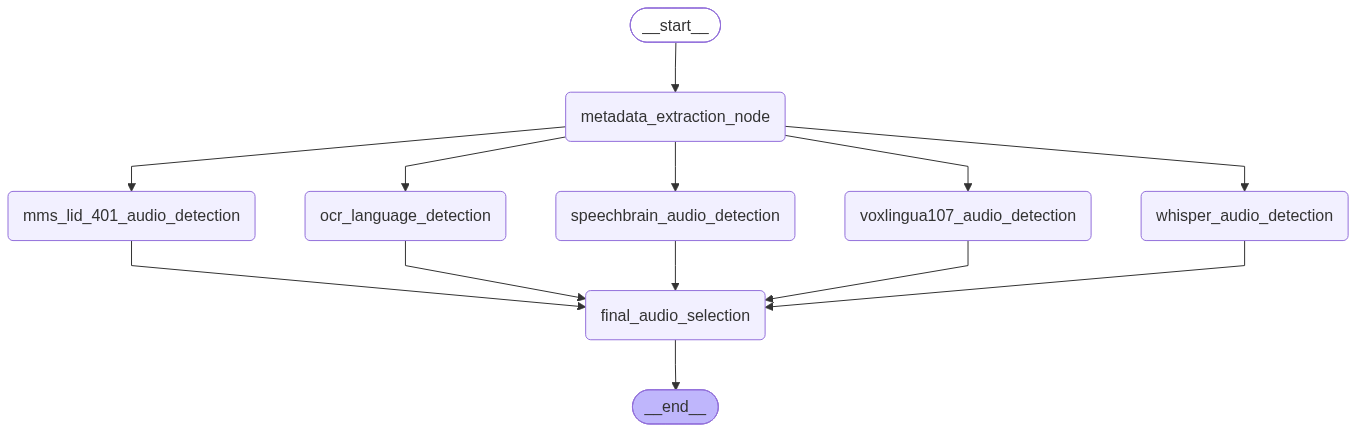

In [14]:
workflow

In [15]:
# 2. Sequential Pre-download step (Only needs to run once to download the zip files)
print("Checking/Downloading EasyOCR model files sequentially...")
use_gpu = torch.cuda.is_available()
easyocr.Reader(['en', 'hi'], gpu=use_gpu)
easyocr.Reader(['en', 'ur'], gpu=use_gpu)
print("EasyOCR models verified on disk!")

Using CPU. Note: This module is much faster with a GPU.


Checking/Downloading EasyOCR model files sequentially...


d:\factlens\.venv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
Using CPU. Note: This module is much faster with a GPU.


EasyOCR models verified on disk!


In [16]:
initial_state = {"video_path" : "D:/factlens/video.mp4"}

final_state = workflow.invoke(initial_state)

print(final_state)

Using CPU. Note: This module is much faster with a GPU.
d:\factlens\.venv\Lib\site-packages\speechbrain\utils\fetching.py:153: UserWarning: Using SYMLINK strategy on Windows for fetching potentially requires elevated privileges and is not recommended. See `LocalStrategy` documentation.
  warnings.warn(


[SpeechBrain Error] [WinError 1314] A required privilege is not held by the client: 'C:\\Users\\rudra\\.cache\\huggingface\\hub\\models--speechbrain--lang-id-commonlanguage_ecapa\\snapshots\\9d809a7e1fdf48afa53e1b41ee8ae0af9ce46308\\hyperparams.yaml' -> 'd:\\factlens\\model_cache\\sb_cv\\hyperparams.yaml'
[VoxLingua Error] [WinError 1314] A required privilege is not held by the client: 'C:\\Users\\rudra\\.cache\\huggingface\\hub\\models--speechbrain--lang-id-voxlingua107-ecapa\\snapshots\\0253049ae131d6a4be1c4f0d8b0ff483a0f8c8e9\\hyperparams.yaml' -> 'd:\\factlens\\model_cache\\sb_vox\\hyperparams.yaml'


Loading weights: 100%|██████████| 1098/1098 [00:01<00:00, 1059.19it/s]
Using CPU. Note: This module is much faster with a GPU.
d:\factlens\.venv\Lib\site-packages\speechbrain\dataio\dataloader.py:225: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  self.__old_init__(loader, *args, **kwargs)


{'video_path': 'D:/factlens/video.mp4', 'valid': True, 'readable': True, 'filename': 'video.mp4', 'extension': '.mp4', 'mime_type': 'video/mp4', 'file_size_bytes': 5144107, 'file_size_mb': 4.91, 'duration_seconds': 49.57, 'fps': 30.0, 'frame_count': 1487, 'resolution': '360x640', 'whisper_result': {'audio_languages': ['hi']}, 'mms_result': {'audio_languages': ['hi']}, 'vox_result': {'audio_languages': []}, 'speechbrain_result': {'audio_languages': []}, 'audio_languages': ['hi'], 'ocr_languages': ['hi'], 'audio_path': 'temp1\\video.wav'}


In [16]:
print(final_state.get("audio_languages")[0])

hi
